# PROJET MACHINE LEARNING - FARES NOUHAILA -

## PROBLÉMATIQUE CHOISIE: Prédiction du défaut de remboursement d'un prêt immobilier  (CLASSIFICATION) 

### PROBLÉMATIQUE MÉTIER: Évaluer le risque de défaut de remboursement d'un client dans le secteur bancaire. À partir des caractéristiques d'un dossier de prêt immobilier (profil de l'emprunteur, caractéristiques du prêt, historique de crédit), on cherche à prédire si le client sera en défaut de paiement (1: défaut de paiement, 0: remboursement normal) 

## ÉTAPE 1: IMPORT DES LIBRAIRIES ET VISUALISATION DU DATASET

In [2]:
#import des librairies de base 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import des librairies nécessaires au pré-processing 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest

#import des librairies d'algorithmes ML
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.tree import plot_tree
from sklearn.neural_network import MLPClassifier

#import de librairies de métriques d'évaluation 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import jaccard_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import RandomizedSearchCV

#import de la librairie pour exporter le modèle final en .pkl
import joblib

In [3]:
#chargement du dataset 
df = pd.read_csv('Loan_Default.csv')

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dataset chargé : 148670 lignes × 34 colonnes


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## ÉTAPE 2: ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
#### CETTE ÉTAPE NOUS PERMET DE VÉRIFIER LE NOMBRE DE VALEURS MANQUANTES, LES VALEURS NUMÉRIQUES ET CATÉGORIELLES, DE VOIR LA DISTRIBUTION DE LA VALEUR CIBLE (TARGET QUI EST : TEST RESULTS), DE VOIR LA CORRÉLATION ENTRE LA VALEUR CIBLE ET LES AUTRES VARIABLES. 

In [4]:
#Vérification des informations générales et les staistiques descriptives du dataset
print("INFORMATIONS GÉNÉRALES")
df.info(), df.dtypes

print("STATISTIQUES DESCRIPTIVES")
df.describe().T

INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfron

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


In [5]:
#Vérification des valeurs manquantes
print("VALEURS MANQUANTES PAR COLONNE")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum().sort_values(ascending=False) / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Nombre de NaN': missing, '% manquant': missing_pct})
missing_df = missing_df[missing_df['Nombre de NaN'] > 0]
missing_df

VALEURS MANQUANTES PAR COLONNE


,Nombre de NaN,% manquant
Upfront_charges,39642,26.66
Interest_rate_spread,36639,24.64
rate_of_interest,36439,24.51
dtir1,24121,16.22
LTV,15098,10.16
property_value,15098,10.16
income,9150,6.15
loan_limit,3344,2.25
approv_in_adv,908,0.61
submission_of_application,200,0.13


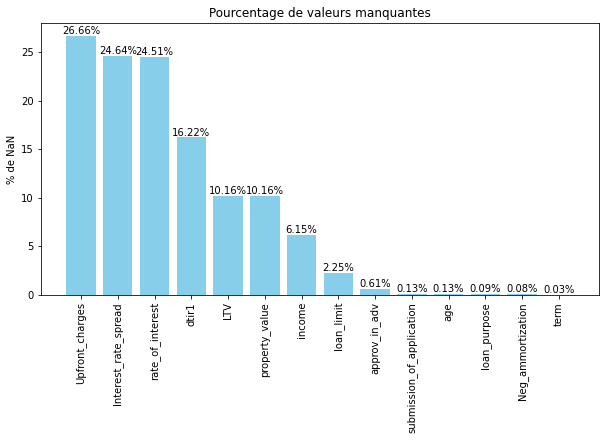

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df['% manquant'], color='skyblue')

#ajout des pourcentages au-dessus des barres
for i, val in enumerate(missing_df['% manquant']):
    plt.text(i, val, f'{val}%', ha='center', va='bottom')
plt.title("Pourcentage de valeurs manquantes")
plt.xticks(rotation=90)
plt.ylabel("% de NaN")
plt.show()

In [7]:
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


### On remarque que les variables ayant le plus de valeurs manquantes sont celles liées aux frais et aux taux (Upfront_charges, Interest_rate_spread) ces variables ont probablement un grand impact prédictif, ce qui nécessitera une stratégie d'imputation (par médiane ou KNN imputer).
### On remarque également une corrélation logique entre property_value et LTV (loan to value) puisqu'ils ont exactement le même taux de valeurs manquantes (10.16%), prouvant que l'une dépend de l'autre.

## Distribution de la variable cible 

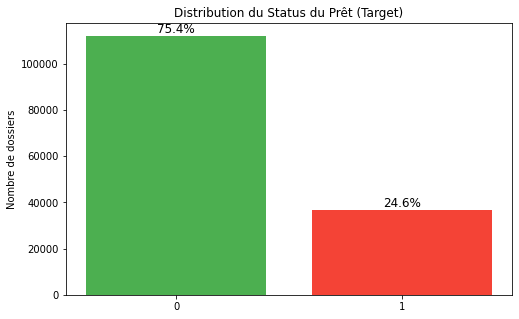

In [8]:
# Calcul des proportions
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(['0', '1'], status_counts.values, color=['#4CAF50', '#F44336'])

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{status_pct.iloc[i]:.1f}%', ha='center', va='bottom', fontsize=12)

plt.title("Distribution du Status du Prêt (Target)")
plt.ylabel("Nombre de dossiers")
plt.show()

### On remarque que la classe 0 (75,4%) est majoritaire par rapport à la classe 1, ce qui montre un désequilibre modéré. Ceci laisse penser à l'utilisation du F1-score (equilibre entre pécision et recall) pour des classes désequilibrées.

## Distribution des variables numériques

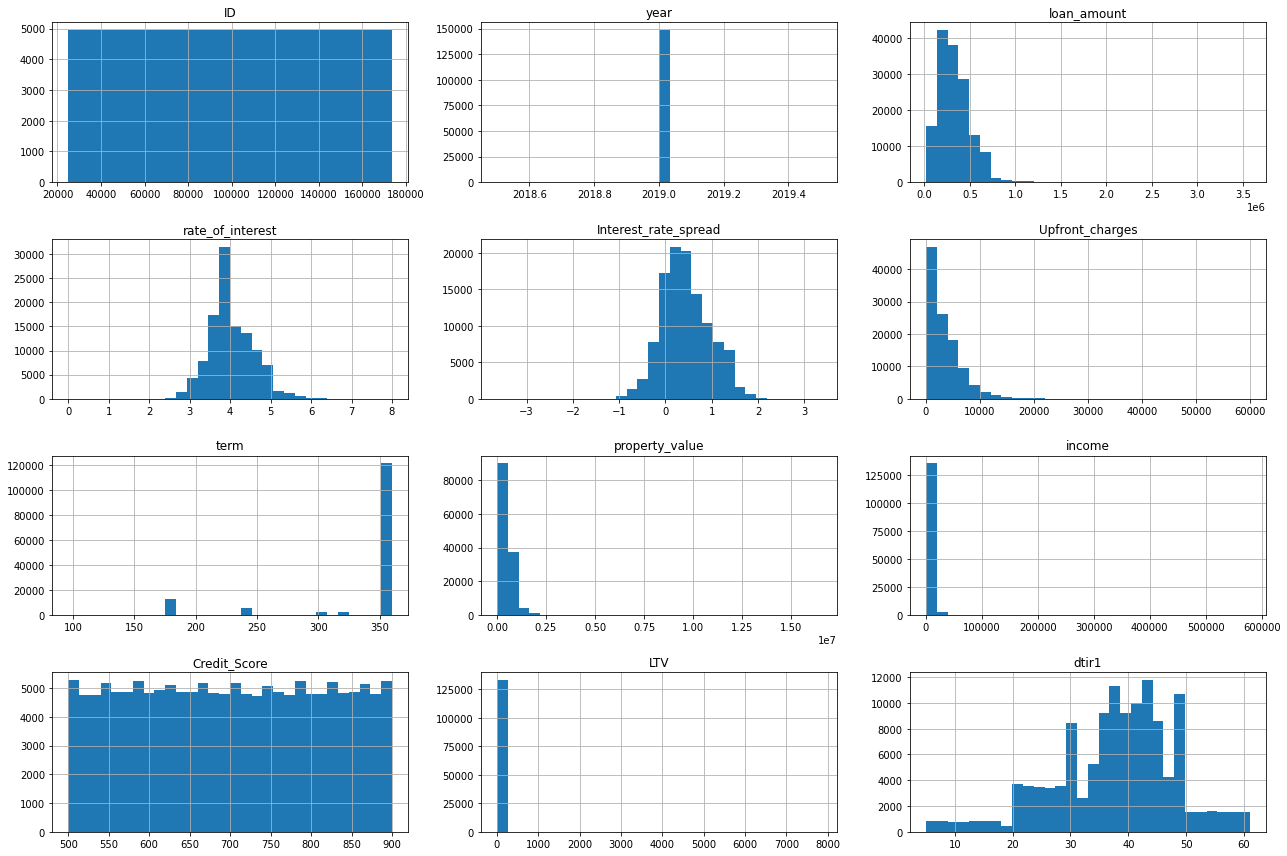

In [9]:
# On sélectionne les variables numériques sauf la variable cible
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Status')

# visualisation de la distribution via histogramme
df[num_cols].hist(
    figsize=(18,12),
    bins=30
)
plt.tight_layout()
plt.show()

### Ces graphes nous permettent de visualiser une asymétrie droite marquée (Right-Skewed) : Les variables financières (loan_amount, property_value, income) sont très étirées vers la droite, ce qui justifie d'utiliser le passage au Log ou un RobustScaler pour atténuer l'impact des montants extrêmes. On remarque également des valeurs des valeurs discrètes pour certaines variables et des distributions normales pour d'autres. 

In [10]:
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


## Distribution des variables catégorielles

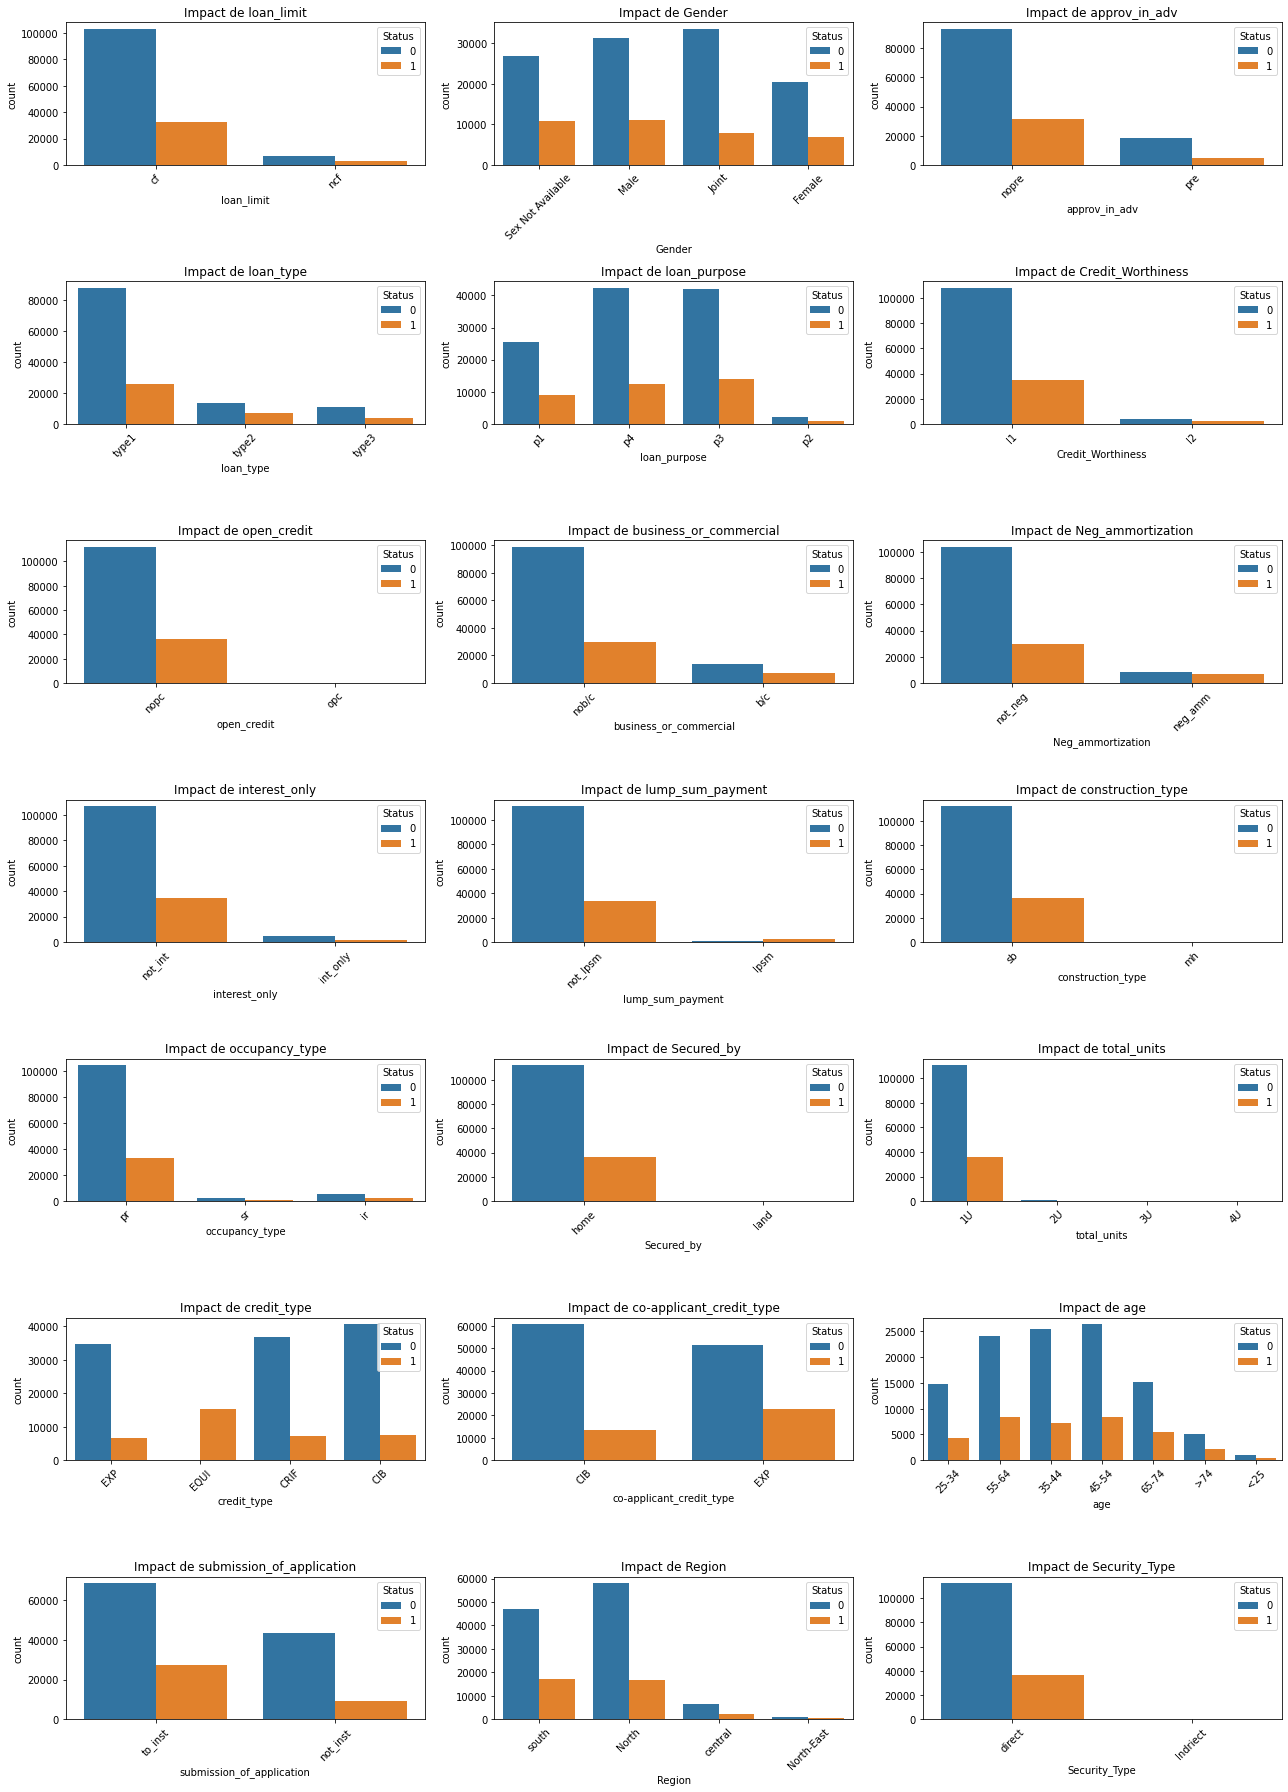

In [11]:
#On liste les colonnes catégorielles
cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(7, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Status', ax=axes[i]) # countplot pour compter le nbre d'occurrence pour chaque catégorie
    axes[i].set_title(f'Impact de {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### On observe visuellement une forte dominance de la classe Status 0 (non-défaut). La classe Status 1 (défaut) est minoritaire.

### Dans cette partie, on va comparer chaque variable catégorielle avec la variable cible on utilisant le tableau de contingence (crosstab) et le test de chi-deux, pour vérifier s'il existe une relation statistiquement significative entre les variables et la cible. 

In [12]:
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include='object').columns
chi2_results = [] #liste pour stocker les résultats 

for col in cat_cols: # Boucle sur les variables
    crosstab = pd.crosstab(df[col], df['Status'])# Table de contingence
    chi2, p, dof, expected = chi2_contingency(crosstab)# Test du Khi-deux
    chi2_results.append({ # Stockage des résultats
        'Variable': col,
        'Chi2 Statistic': chi2,
        'P-value': p,
        'Relation significative': 'Oui' if p < 0.05 else 'Non'
    })
chi2_df = pd.DataFrame(chi2_results)
chi2_df = chi2_df.sort_values(by='P-value')
chi2_df

,Variable,Chi2 Statistic,P-value,Relation significative
10,lump_sum_payment,5237.827442,0.000000e+00,Oui
18,submission_of_application,2171.709755,0.000000e+00,Oui
16,co-applicant_credit_type,3092.392571,0.000000e+00,Oui
15,credit_type,52135.280705,0.000000e+00,Oui
8,Neg_ammortization,3610.208104,0.000000e+00,Oui
3,loan_type,1309.958143,3.517253e-285,Oui
7,business_or_commercial,1272.807998,9.172191e-279,Oui
1,Gender,1043.600850,6.260048e-226,Oui
0,loan_limit,427.398487,5.985647e-95,Oui
19,Region,380.456330,3.786057e-82,Oui


In [13]:
chi2_df = chi2_df.sort_values(by='Chi2 Statistic', ascending=False)
chi2_df

,Variable,Chi2 Statistic,P-value,Relation significative
15,credit_type,52135.280705,0.000000e+00,Oui
10,lump_sum_payment,5237.827442,0.000000e+00,Oui
8,Neg_ammortization,3610.208104,0.000000e+00,Oui
16,co-applicant_credit_type,3092.392571,0.000000e+00,Oui
18,submission_of_application,2171.709755,0.000000e+00,Oui
3,loan_type,1309.958143,3.517253e-285,Oui
7,business_or_commercial,1272.807998,9.172191e-279,Oui
1,Gender,1043.600850,6.260048e-226,Oui
0,loan_limit,427.398487,5.985647e-95,Oui
19,Region,380.456330,3.786057e-82,Oui


### Les résultats du test du Khi-deux montrent que toutes les variables catégorielles présentent une relation statistiquement significative avec la variable cible. Cette situation s’explique notamment par la grande taille du dataset, qui rend le test très sensible aux faibles différences entre catégories. 

### Cependant, certaines variables présentent des statistiques Khi-deux beaucoup plus élevées, indiquant une relation plus forte avec le défaut de paiement, notamment le credit-type, lump_sum_payment (le mode de paiement forfaitaire), Neg_ammortization(l'amortissement. négatif), co-applicant_credit_type (co-emprunteur), submission_of_application(soumission du dossier). Ces variables auront ainsi un grand effet prédicteur pour notre modèle. 

## MATRICE DE CORRÉLATION NUMÉRIQUE

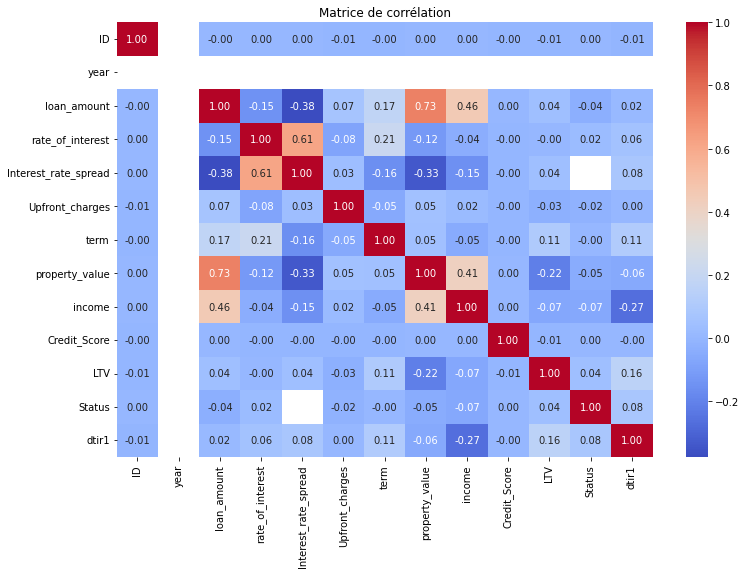

Status                  1.000000
dtir1                   0.078083
income                  0.065119
property_value          0.048864
LTV                     0.038895
loan_amount             0.036825
rate_of_interest        0.022957
Upfront_charges         0.019138
Credit_Score            0.004004
ID                      0.001703
term                    0.000240
year                         NaN
Interest_rate_spread         NaN
Name: Status, dtype: float64


In [14]:
# On sélectionne les variables numériques
num_cols = df.select_dtypes(include=['int64', 'float64'])
# Matrice de corrélation
corr_matrix = num_cols.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True,
            fmt='.2f')

plt.title("Matrice de corrélation")
plt.show()

# Corrélation avec la variable cible Status
corr_status = corr_matrix['Status'].abs().sort_values(ascending=False) #on fait un classement en valeur absolue car une corrélation négative est aussi importante 
print(corr_status)

### On remarque que les coefficients de corrélation entre les variables numériques et la variable cible Status sont globalement faibles. La variable la plus corrélée est dtir1, mais avec une corrélation limitée. Cela indique qu’aucune variable numérique prise individuellement n’explique fortement le défaut de paiement de manière linéaire. Les résultats obtenus suggèrent donc que la performance des modèles dépendra davantage de la combinaison des variables, notamment catégorielles, que d’une seule variable numérique fortement corrélée à la cible. 

### Analyse VIF

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Status'])
# Suppression des NaN
X = X.dropna()

# Calcul du VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif = vif.sort_values(by="VIF", ascending=False)
print(vif)

                Variable         VIF
1                   year  178.891849
7         property_value    5.537061
2            loan_amount    4.883352
10                   LTV    2.630708
4   Interest_rate_spread    2.197970
3       rate_of_interest    1.972368
8                 income    1.509273
6                   term    1.407850
11                 dtir1    1.185117
5        Upfront_charges    1.053188
0                     ID    1.000218
9           Credit_Score    1.000128


In [16]:
df['year']

0         2019
1         2019
2         2019
3         2019
4         2019
          ... 
148665    2019
148666    2019
148667    2019
148668    2019
148669    2019
Name: year, Length: 148670, dtype: int64

### L’analyse du facteur d’inflation de variance (VIF) montre que la majorité des variables numériques présentent des valeurs faibles ou modérées, indiquant une absence globale de multicolinéarité importante dans le dataset. la variable year a un VIF élevée car elle ne présente aucune variabilité, c une valeur unique et n'apportera aucune information au modèle.

### Vérification des outliers 

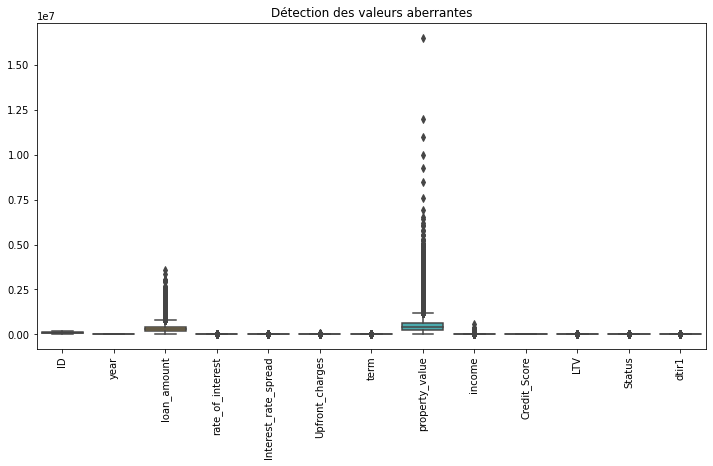

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=90)
plt.title("Détection des valeurs aberrantes")
plt.show()

Variable : loan_amount
Nombre d'outliers : 1895


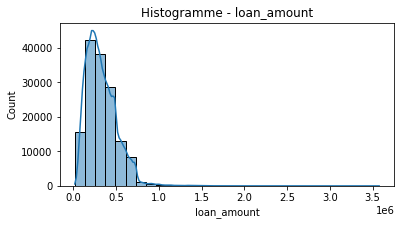

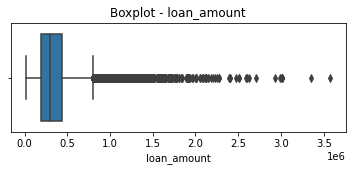

Variable : rate_of_interest
Nombre d'outliers : 856


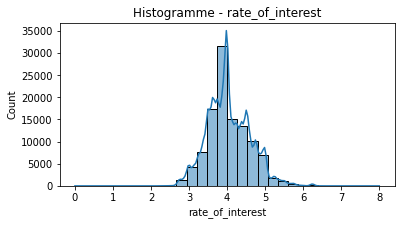

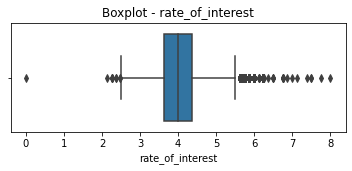

Variable : Interest_rate_spread
Nombre d'outliers : 445


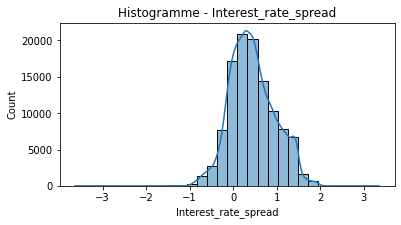

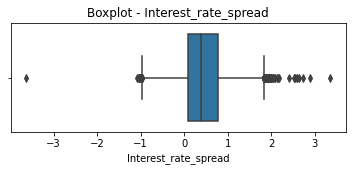

Variable : Upfront_charges
Nombre d'outliers : 2880


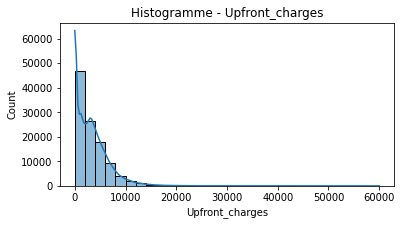

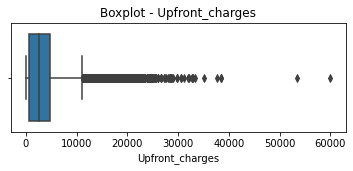

Variable : property_value
Nombre d'outliers : 5266


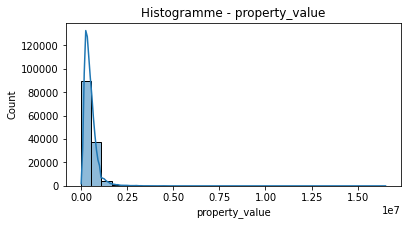

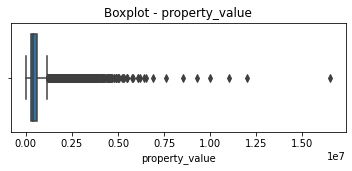

Variable : income
Nombre d'outliers : 6546


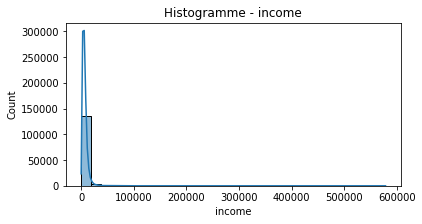

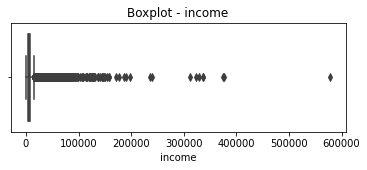

Variable : Credit_Score
Nombre d'outliers : 0


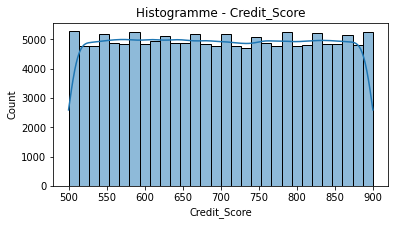

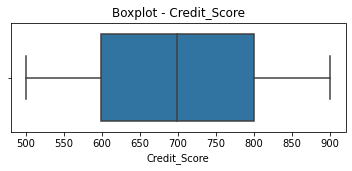

Variable : LTV
Nombre d'outliers : 1882


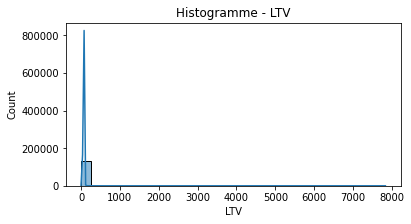

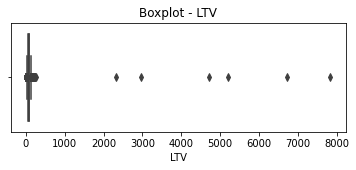

Variable : dtir1
Nombre d'outliers : 2013


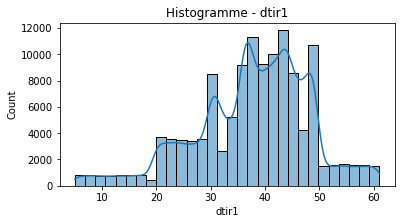

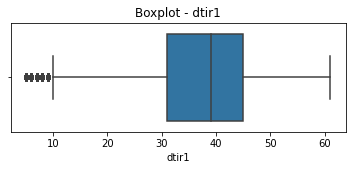

In [18]:
# Variables numériques (exclure id et year)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['ID', 'year','term','Status'], errors='ignore')  # important

# Boucle sur toutes les variables numériques
for col in num_cols:
    # Calcul IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Détection des outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Affichage
    print(f"Variable : {col}")
    print(f"Nombre d'outliers : {len(outliers)}")

    # Histogramme
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogramme - {col}')
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

### On identifie un nombre important d'outliers, notamment sur le revenu (income) et la valeur des biens (property_value) ceci confirme la présence de distributions asymétriques typiques des données financières. Nous envisagerons donc des transformations logarithmique pour stabiliser les modèles de machine learning lors de la phase de prétraitement.

## ÉTAPE 3: PRÉ-PROCESSING

### Dans cette étape de preprocessing on va transformer les données brutes en un format optimal en nettoyant les valeurs manquantes (simple imputer par médiane), en encodant les variables catégorielle (ordinal encoder) et en normalisant les échelles numériques (standard scaler) afin de garantir la performance et la stabilité des modèles de Machine Learning qu'on utilisera par la suite. nous allons également faire du feature engineering pour créer de nouvelle variables optimales et enrichir l'information existante.

### Nous avons choisi l'imputation par médiane et le RobustScaler pour neutraliser l'influence des nombreux outliers financiers (revenus, montants), et l'OrdinalEncoder pour encoder efficacement les variables catégorielles sans multiplier artificiellement la dimension du dataset. 

### Lors de la première exécution de la boucle d’entraînement, des performances anormalement élevées ont été observées : la quasi-totalité des modèles affichaient un AUC-ROC de 1.0000, y compris des algorithmes simples comme Decision Tree et AdaBoost. Ce résultat, physiquement improbable sur un dataset de crédit réel, a  suscité des doutes quant à la présence de data leakage.
### On a donc fait un test sur un arbre de décision à profondeur 1 (decision stump) qui a été entraîné afin d’identifier une éventuelle feature dominante unique : l’AUC obtenue était de 0.7495 (feature utilisée : approv_in_adv), ce qui est normal et excluait la présence d’une variable quasi-parfaite isolée.
### La cause réelle a finalement été identifiée grâce à l’analyse des feature importances de Random Forest, qui a révélé une concentration anormale du pouvoir prédictif sur trois variables : rate_of_interest, Interest_rate_spread et Upfront_charges. D’un point de vue métier, ces trois variables constituent un leakage temporel : dans le processus bancaire réel, le taux d’intérêt et les frais associés sont déterminés après l’évaluation du profil de risque de l’emprunteur, et non avant. Leur présence dans le dataset permettait donc aux modèles de lire indirectement la cible, faussant l’ensemble des résultats.

### Ces trois colonnes ont donc été supprimées du dataset avant tout split ou entraînement. voici la suite du code corrigé sans data leakage

### Néttoyage du dataset et feature engineering

In [19]:
# On Supprime l'ID et les colonnes qui causent la fuite (Leakage)
# On retire: rate_of_interest, Interest_rate_spread, Upfront_charges
cols_leakage = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']
cols_constant = [col for col in df.columns if df[col].nunique() <= 1 or col == 'ID']
cols_to_drop = list(set(cols_leakage + cols_constant))

df_clean = df.drop(columns=cols_to_drop).copy()

# On utilise ajoute du feature engineering avec income_loan_ratio
df_clean['income_loan_ratio'] = df_clean['income'] / df_clean['loan_amount'].replace(0, np.nan)#charge du prêt vs revenu

# Séparation X (features) et y (cible)
X = df_clean.drop(columns=['Status'])
y = df_clean['Status']

# Identification automatique des types
num_features = X.select_dtypes(exclude='object').columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

### Construction du pipeline de pré-processing 

### on va construire un flux de travail automatisé pour le svaleurs numériques et catégorielles

In [20]:
#Pipeline pour les nombres
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),#on remplace les nan par la mediane qui est plus robuste que la moyenne
    ('scaler', StandardScaler())#on met le même échelle pour tt les variables numériques
])
#Pipeline pour le texte
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),#on remplace les nan par la catégorie la plus fréquente
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))#ordinal encoder pour plus d'efficacite. L'option handle_unknown est une sécurité
])
#On combine le tout
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])
print("Pipeline de pré-processing construit")

Pipeline de pré-processing construit


## ÉTAPE 4: SÉPARATION TRAIN/TEST

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)#On garde 20% des données pour le test final et 80% pour l'entraînement.
#Avec stratify=y, on garantit que la proportion de "Status 1" est la même dans le Train et dans le Test.

print(f"Train : {X_train.shape[0]:,} lignes , Test : {X_test.shape[0]:,} lignes")
print(f"Variables utilisées : {len(X.columns)} features")

Train : 118,936 lignes , Test : 29,734 lignes
Variables utilisées : 29 features


## ÉTAPE 5: ENTRAÎNEMENT ET COMPARAISON DE 12 MODÈLES

In [22]:
MODELS = {
    #les algoriithmes linéaires qui cherchenrt une ligne ou un plan pour séparer les classes
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=42),
    #'SVM':SVC(probability=True, random_state=42, cache_size=1000),
    'Naive Bayes':GaussianNB(),
    #les algorithmes basés sur les arbres, ils posent des questions succéssives
    'Decision Tree':DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest':RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2),
    'Extra Trees':ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=2),
    #le boosting: qui permet de réduire l'erreur de manière séquentielle
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost':XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=2),
    #le bagging: qui permet de prendre des échantillonnages aléatoires avec remplacement. (botstrap aggregating)
    'Bagging':BaggingClassifier(n_estimators=50, random_state=42, n_jobs=2),
    #réseau de neuronnes et KNN (voisins les plus proches)
    'KNN':KNeighborsClassifier(n_neighbors=7, n_jobs=2),
    'MLP Neural Network':MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

In [23]:
results = []
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
#ici on utilise stratifiedkfolds Cross-Validation pour garantir la robustesse de nos résultats
#et dans chaque petit groupe, on s'assure de garder le même pourcentage de défauts (Status 1) que dans le dataset original

print("Lancement de l'entraînement")
# Ajout de la colonne CV AUC dans l'en-tête pour le suivi
print(f"{'Modèle':<25} {'Train Acc':>10} {'Test Acc':>10} {'F1':>10} {'AUC':>10} {'CV AUC':>10}")

for name, model in MODELS.items():
    full_pipe = Pipeline(steps=[    #ici On utilise une version spéciale du pipeline qui autorise le rééchantillonnage
        ('preprocessing', preprocessor), #première étape c'est le préprocessing (on applique les transformations)
        #('smote', SMOTE(random_state=42)),#ici on fait un traitement SMOTE pour que le modèle voie autant de cas de défaut que de cas normaux, parceque le dataset est désequilibré
        ('classifier', model)#Ensuite on envoie les données propres et équilibrées aux algorithmes
    ])
    
    # ici on calcule le score moyen sur 5 divisions différentes pour s'assurer que la performance ne dépend pas du hasard
    cv_scores = cross_val_score(
        full_pipe, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    cv_mean = cv_scores.mean() # Score moyen de la cross-validation 
    #Le Mean AUC est la moyenne de ces 5 tests. C'est un score beaucoup plus robuste et représentatif de la réalité.
    #La Cross-Validation garantit que la performance observée est généralisable à l'ensemble 
    #du dataset et n'est pas le résultat d'un découpage aléatoire favorable
    cv_std = cv_scores.std() # Écart-type (stabilité du modèle)
    
    full_pipe.fit(X_train, y_train)# ENTRAÎNEMENT
    y_pred = full_pipe.predict(X_test)# PRÉDICTIONS
    train_pred = full_pipe.predict(X_train)# Train (IMPORTANT pour détecter overfitting)
    
    if hasattr(full_pipe, "predict_proba"): # #proba indispensable pour AUC ET ROC
        y_proba = full_pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
        
    train_acc = accuracy_score(y_train, train_pred)# Accuracy train,Scores accuracy: pourcentage de bonnes réponses globales
    test_acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)# F1-score équilibre entre précision et recall
    auc = roc_auc_score(y_test, y_proba)# #mesure la capacité du modèle à bien séparer les 2 classes, plus c proche de 1, plus le modèle est parfait 
    
    results.append({
        'Modèle': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1 Score': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'CV Mean AUC': round(cv_mean, 4), # Ajout du score moyen CV aux résultats
        'CV Std': round(cv_std, 4)        # Ajout de l'écart-type aux résultats
    })
    
    # Affichage incluant le score de Cross-Validation
    print(f"{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {f1:>10.4f} {auc:>10.4f} {cv_mean:>10.4f}")

# Classement final basé sur le score de Cross-Validation (plus robuste que le simple test)
results_df = pd.DataFrame(results).sort_values(by='CV Mean AUC', ascending=False)
print("\nCLASSEMENT FINAL (Trié par CV Mean AUC)")
print(results_df)

Lancement de l'entraînement
Modèle                     Train Acc   Test Acc         F1        AUC     CV AUC
Logistic Regression           0.7760     0.7803     0.3167     0.7295     0.7263
Naive Bayes                   0.7647     0.7684     0.1563     0.7142     0.7055
Decision Tree                 0.9336     0.8760     0.7151     0.8172     0.8015
Random Forest                 1.0000     0.8949     0.7432     0.8893     0.8858
Extra Trees                   1.0000     0.8795     0.6943     0.8807     0.8756
Gradient Boosting             0.8884     0.8937     0.7357     0.8849     0.8827
AdaBoost                      0.8761     0.8805     0.7014     0.8693     0.8681
XGBoost                       0.9103     0.9013     0.7648     0.8977     0.8926
Bagging                       0.9993     0.8940     0.7483     0.8824     0.8785
KNN                           0.8700     0.8579     0.6193     0.7997     0.7913
MLP Neural Network            0.9114     0.8864     0.7429     0.8794     0.8667


### Ici on fait une vérification du biais et variance pour voir. s'il y a overfitting ou underfitting

In [24]:
bias_variance_df = pd.DataFrame(results)

#Calcul du Gap (Variance)
bias_variance_df['Gap (Variance)'] = bias_variance_df['Train Accuracy'] - bias_variance_df['Test Accuracy']

def diagnostiquer(row):
    # Un train acc faible (ex < 0.75) indique souvent un biais élevé
    if row['Train Accuracy'] < 0.75:
        return "Biais Élevé (Sous-apprentissage)"
    # Un gap important (ex > 0.05) indique une variance élevée
    elif row['Gap (Variance)'] > 0.05:
        return "Variance Élevée (Overfitting)"
    else:
        return "Bon Équilibre (Généralise bien)"

bias_variance_df['Diagnostic'] = bias_variance_df.apply(diagnostiquer, axis=1)
print("ANALYSE DE LA CAPACITÉ DE GÉNÉRALISATION")
display(bias_variance_df[['Modèle', 'Train Accuracy', 'Test Accuracy', 'Gap (Variance)', 'Diagnostic']].sort_values('Gap (Variance)'))

ANALYSE DE LA CAPACITÉ DE GÉNÉRALISATION


,Modèle,Train Accuracy,Test Accuracy,Gap (Variance),Diagnostic
5,Gradient Boosting,0.8884,0.8937,-0.0053,Bon Équilibre (Généralise bien)
6,AdaBoost,0.8761,0.8805,-0.0044,Bon Équilibre (Généralise bien)
0,Logistic Regression,0.7760,0.7803,-0.0043,Bon Équilibre (Généralise bien)
1,Naive Bayes,0.7647,0.7684,-0.0037,Bon Équilibre (Généralise bien)
7,XGBoost,0.9103,0.9013,0.0090,Bon Équilibre (Généralise bien)
9,KNN,0.8700,0.8579,0.0121,Bon Équilibre (Généralise bien)
10,MLP Neural Network,0.9114,0.8864,0.0250,Bon Équilibre (Généralise bien)
2,Decision Tree,0.9336,0.8760,0.0576,Variance Élevée (Overfitting)
3,Random Forest,1.0000,0.8949,0.1051,Variance Élevée (Overfitting)
8,Bagging,0.9993,0.8940,0.1053,Variance Élevée (Overfitting)


### L’entraînement de 11 algorithmes sur ce dataset, révèle des performances globalement solides avec un AUC-ROC compris entre 0.71 et 0.90. Le classement final est basé sur le CV Mean AUC (validation croisée 5-folds stratifiée), plus robuste qu’une simple évaluation sur le test set car il mesure la stabilité du modèle sur 5 partitions différentes des données. 

### on remarque 3 modèles performants et stables: XGBoost, Gradient Boosting, et random forest. Tous affichent des critères CV AUC, TEST AUC, F1 score, gap train/test satisfaisant. bien que random forest affiche un overfitting, il reste candidat au tunning car ce overfitting peut être corrigé via la limitation de la profondeur des arbres et le nombre minimum de samples. 

## ÉTAPE 6: GRAPHES DE PERFORMANCE

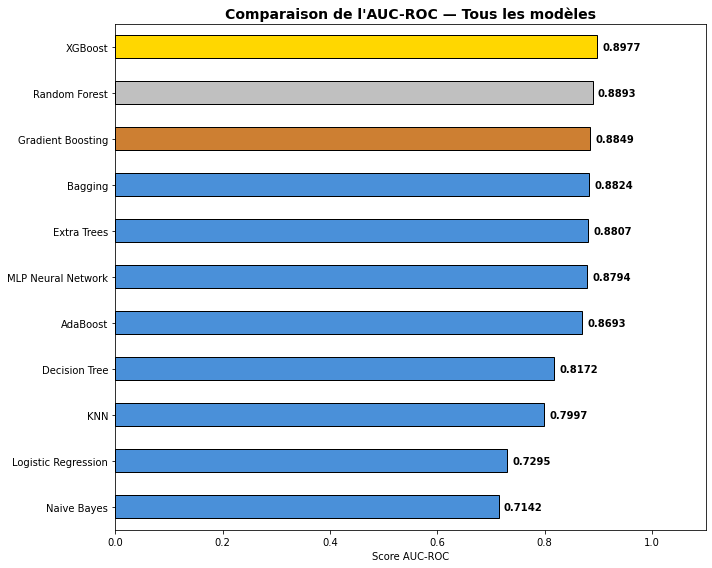

In [25]:
# Configuration des couleurs
colors = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['#4A90D9'] * (len(results_df) - 3)
fig, ax = plt.subplots(figsize=(10, 8))
# On trace l'AUC-ROC (la métrique la plus importante)
results_df.sort_values('AUC-ROC', ascending=True).plot(
    x='Modèle', y='AUC-ROC', kind='barh', ax=ax, color=colors[::-1], edgecolor='black', legend=False
)
# On ajoute des valeurs numériques à côté des barres
for i, v in enumerate(results_df.sort_values('AUC-ROC', ascending=True)['AUC-ROC']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('Comparaison de l\'AUC-ROC — Tous les modèles', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Score AUC-ROC')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [26]:
# on identifier le Top 3 à partir des derniers résultats
top3_models_names = results_df.head(3)['Modèle'].tolist()
# On crée et entraîne un petit dictionnaire pour ces 3 modèles
# Cela évite l'erreur "fitted_pipelines not defined"
fitted_pipelines = {}
for name in top3_models_names:
    pipe = Pipeline(steps=[('pre', preprocessor), ('clf', MODELS[name])])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

print(f"Top 3 sélectionnés : {top3_models_names}")

Top 3 sélectionnés : ['XGBoost', 'Random Forest', 'Gradient Boosting']


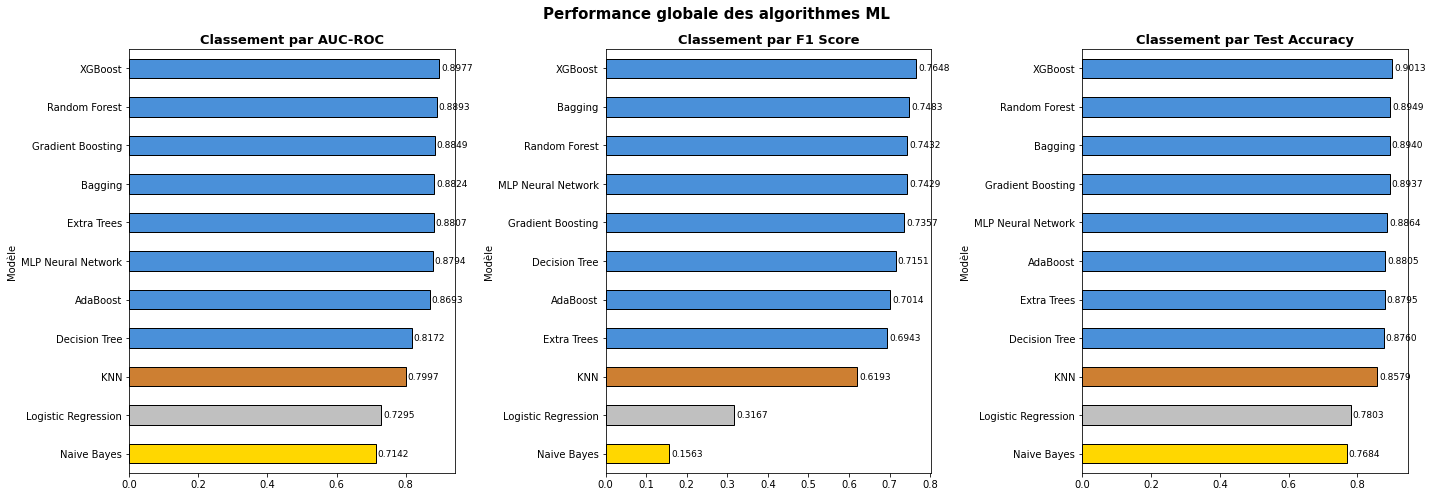

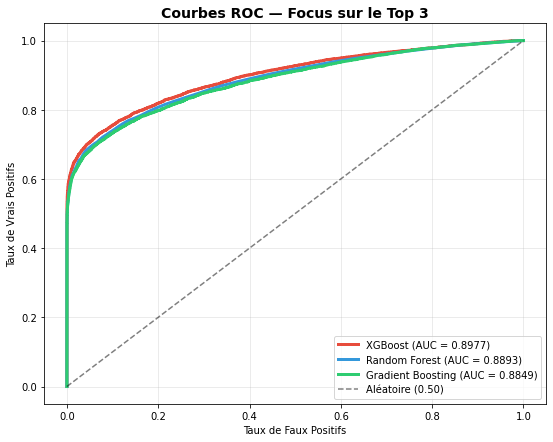

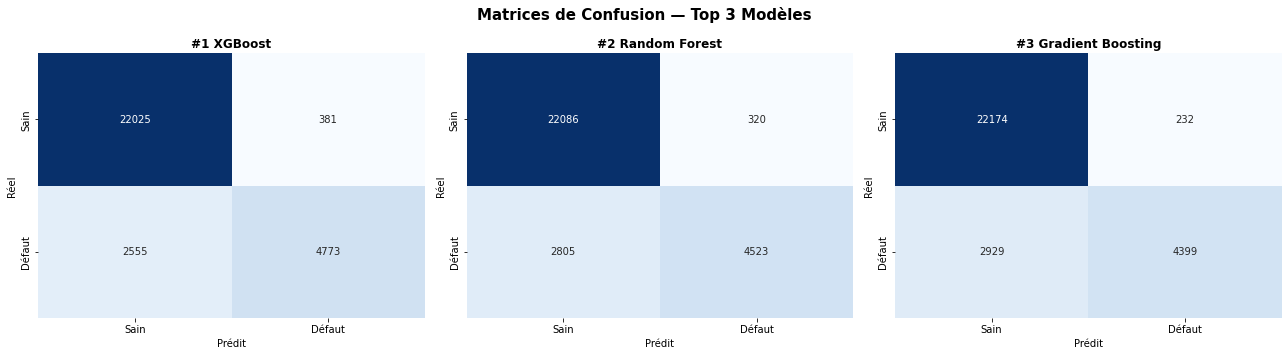

In [27]:
#Graphes de performance comparatifs 
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['#4A90D9'] * (len(results_df) - 3)

metrics = ['AUC-ROC', 'F1 Score', 'Test Accuracy'] 

for ax, metric in zip(axes, metrics):
    results_df.sort_values(metric, ascending=False).plot(
        x='Modèle', y=metric, kind='barh', ax=ax, 
        color=colors[::-1], edgecolor='black', legend=False
    )
    ax.set_title(f"Classement par {metric}", fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(results_df.sort_values(metric, ascending=False)[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Performance globale des algorithmes ML', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#Courbes ROC du Top 3
plt.figure(figsize=(9, 7))
colors_roc = ['#E74C3C', '#3498DB', '#2ECC71']

for name, color in zip(top3_models_names, colors_roc):
    y_proba = fitted_pipelines[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba) #Calcule le taux de faux positifs (FPR) et le taux de vrais positifs (TPR).
    auc_val = roc_auc_score(y_test, y_proba) #Calcule l'aire sous la courbe (AUC). Plus elle est proche de 1, meilleur est le modèle.
    plt.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire (0.50)') #Trace une ligne diagonale pointillée noire représentant un modèle aléatoire
plt.title('Courbes ROC — Focus sur le Top 3', fontsize=14, fontweight='bold')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#Matrices de Confusion du Top 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(top3_models_names):
    y_pred = fitted_pipelines[name].predict(X_test) #Obtient les prédictions finales (0 ou 1) du modèle.
    cm = confusion_matrix(y_test, y_pred) #Calcule la matrice 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sain','Défaut'], yticklabels=['Sain','Défaut'],#Remplace les 0/1 par des noms explicites ("Sain", "Défaut")
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'#{idx+1} {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Réel')

plt.suptitle('Matrices de Confusion — Top 3 Modèles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation: 
### FP( fausse alerte) : client sain classé comme défaut; FN(manqué): client en défaut classé sain.

### La courbe ROC de XGBoost (en rouge) est la plus haute. Cela signifie qu'à n'importe quel niveau de risque choisi par la banque, XGBoost est le modèle qui détecte le plus de clients en défaut tout en faisant le moins d'erreurs sur les clients sains. Il réduit significativement le nombre de Faux Négatifs (clients en défaut non détectés) par rapport au Random Forest et Gradient Boosting, passant de 2805 et 2929 à 2555 erreurs. Il minimise ainsi les pertes financières potentielles. Sa matrice de confusion montre également qu'il rejette très peu de clients sains (381 seulement).
### Si l'objectif de la banque est de minimiser strictement le rejet de bons clients, le Gradient Boosting est optimal car il reduit les faux positives (232, le plus bas des 3). Cependant, dans une optique de gestion prudente du risque de crédit, XGBoost reste le meilleur choix car il offre la réduction la plus importante des pertes financières en réduisant les False Negatives. 

## ÉTAPE 7: TUNING DES 3 MEILLEURS MODÈLES 

### Le tunning est l'étape finale pour extraire le maximum de performance des modèles. Le but du tuning est de trouver l'équilibre parfait pour éviter deux erreurs majeures: underfitting et overfitting. Dans le code qui suit on utilise RandomizedSearchCV qui permet , au lieu de tester toutes les combinaisons possibles, il pioche combinaisons (n_iter) au hasard. C'est le meilleur compromis entre temps de calcul et gain de performance. 

In [28]:
param_grids = {
    'XGBoost': {
        #on utilise classifier parce que le modèle est dans un Pipeline. 
        #On doit dire à Python : "Va dans l'étape nommée classifier et règle les paramètres"
        'classifier__n_estimators': [100, 300, 500], #Combien d'arbres on construit
        'classifier__learning_rate': [0.01, 0.05, 0.1],#Vitesse d'apprentissage
        'classifier__max_depth': [3, 5, 7],#Complexité de chaque arbre (la profondeur)
        'classifier__subsample': [0.8, 1.0]#pourrcentage de données utilisées pour chaque arbre
    }, #pour chaque paramètre on met 3 valeurs ce qui permet à la fonction RandomizedSearchCV de comparer des comportements différents
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    }
}

In [29]:
tuning_results = [] #pour stocker les scores avant/après
best_pipelines = {} #pour sauvegarder les modèles optimisés

for name in top3_models_names:
    print(f"Optimisation de {name}...")
    
    # Création du pipeline de base. le tuning doit se faire sur l'ensemble du processus : 
    #le preprocessor prépare les données, puis le classifier apprend
    pipe = Pipeline(steps=[('pre', preprocessor), ('classifier', MODELS[name])]) 
    
    # Recherche aléatoire (20 essais pour être rapide)
    search = RandomizedSearchCV(pipe, param_grids[name], n_iter=20, 
                                scoring='roc_auc', cv=3, n_jobs=2, random_state=42)
    #pipe : L'objet à tester, param_grids[name] : La liste des valeurs à tester pour ce modèle précis.
    #n_iter=20 : Au lieu de tester toutes les combinaisons, on en choisit 20 au hasard pour gagner du temps.
    #scoring='roc_auc' : le critère de réussite. On cherche la combinaison qui donne la plus grande aire sous la courbe.
    #cv=3 : Chaque test est répété sur 3 découpages différents des données (Cross-Validation) pour être sûr que le résultat n'est pas dû au hasard.
    
    search.fit(X_train, y_train) #ici la machine lance les 20 entraînements, calcule les scores, et garde en mémoire la meilleure combinaison trouvée.
    
    # Sauvegarde du meilleur modèle et des scores
    auc_before = results_df.loc[results_df['Modèle']==name, 'AUC-ROC'].values[0] #résultats précedents
    auc_after = search.best_score_ #on recupère le score trouvée par la meilleure combinaison de search
    
    best_pipelines[name] = search.best_estimator_
    tuning_results.append({
        'Modèle': name,
        'AUC Avant': auc_before,
        'AUC Après': auc_after,
        'Gain': auc_after - auc_before
    })

tuning_df = pd.DataFrame(tuning_results)
print("Tuning terminé !")

Optimisation de XGBoost...
Optimisation de Random Forest...
Optimisation de Gradient Boosting...


/opt/anaconda3/envs/hay/lib/python3.8/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Tuning terminé !


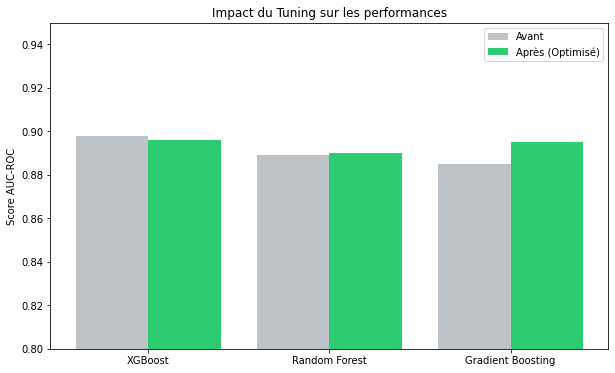

In [30]:
#ici on fait un graphique en barres groupées. Son but est de mettre côte à côte les performances "Avant" et "Après" 
#pour voire le gain apporté par ce travail d'optimisation.
x = np.arange(len(tuning_df))
plt.figure(figsize=(10, 6))

plt.bar(x - 0.2, tuning_df['AUC Avant'], 0.4, label='Avant', color='#bdc3c7')
plt.bar(x + 0.2, tuning_df['AUC Après'], 0.4, label='Après (Optimisé)', color='#2ecc71')

plt.xticks(x, tuning_df['Modèle'])
plt.ylabel('Score AUC-ROC')
plt.title('Impact du Tuning sur les performances')
plt.legend()
plt.ylim(0.8, 0.95) # On zoom sur la zone intéressante
plt.show()

### - Pour le tuning de XGBOOST, on remarque une légère baisse ce qui confirme qu'on ne peut pas faire beaucoup mieux que ton score initial de ~0.898.
### - le score est quasi identique pour Random forest réputé pour sa forte stabilité.
### - pour le gradientboosting, on remarque une amélioration. le Gradient Boosting standard de Scikit-Learn est souvent "sous-paramétré" par défaut. ce tuning a permis de trouver un meilleur équilibre, le faisant passer d'environ 0.885 à 0.895.

### L'étape d'optimisation par RandomizedSearchCV confirme la pertinence de nos choix initiaux. Bien que le Gradient Boosting ait bénéficié d'une nette amélioration après tuning, XGBoost conserve la première place avec un AUC-ROC de 0.8977. La convergence des scores après optimisation démontre que le modèle a bien saisi l'essentiel de l'information prédictive disponible dans les variables de crédit.

## ÉTAPE 8: ÉVALUATION COMPLÈTE DU MODÈLE  FINAL

In [35]:
#Sélection du meilleur modèle
if tuning_results:#On vérifie si l'étape de tuning a été effectuée
    best_model_name = tuning_df.iloc[0]['Modèle']#On récupère le nom du modèle qui est arrivé en première position (selon AUC).
    final_pipeline = best_pipelines[best_model_name]#On extrait le pipeline complet (prétraitement + modèle optimisé) correspondant à ce meilleur modèle.
else:#Si le tuning n'a pas eu lieu, on prend par défaut le meilleur modèle des tests initiaux.
    best_model_name = results_df.iloc[0]['Modèle']
    final_pipeline = fitted_pipelines[best_model_name]

print(f"Le meilleur modèle ML est: {best_model_name}")

#Calcul des métriques finales
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]
y_proba_train = final_pipeline.predict_proba(X_train)[:, 1]

auc_test = roc_auc_score(y_test, y_proba_final)#La performance réelle sur des clients "inconnus"
auc_train = roc_auc_score(y_train, y_proba_train)#La performance sur les clients que le modèle a déjà vus pendant l'entraînement

print(f"\nPerformance finale ({best_model_name})")
print(f"AUC-ROC Train : {auc_train:.4f}")
print(f"AUC-ROC Test  : {auc_test:.4f}")
print(f"Gap (Overfit) : {auc_train - auc_test:.4f}")#différence entre les 2

#Rapport détaillé
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_final, target_names=['Sain (0)', 'Défaut (1)']))
#précision: Quand le modèle prédit un Défaut, a-t-il raison.
#recall: Sur tous les vrais fraudeurs, combien le modèle en a capturé.
#f1-score: C'est l'indicateur d'équilibre du modèle.

Le meilleur modèle ML est: XGBoost

Performance finale (XGBoost)
AUC-ROC Train : 0.9237
AUC-ROC Test  : 0.9014
Gap (Overfit) : 0.0223

Rapport de classification :
              precision    recall  f1-score   support

    Sain (0)       0.89      0.99      0.94     22406
  Défaut (1)       0.94      0.65      0.76      7328

    accuracy                           0.90     29734
   macro avg       0.92      0.82      0.85     29734
weighted avg       0.91      0.90      0.90     29734



### Comme le gap est inférieur à 3%, on peut affirmer que le modèle n'apprend pas par coeur. Il a appris des règles générales sur le risque de crédit. Le modèle est robuste. Il se comportera de la même manière sur de nouveaux clients qu'il n'a jamais vus. Globalement, le modèle prend la bonne décision pour 9 clients sur 10.
### le modèle XGBoost atteint un AUC-ROC de 0.90 sur le test set avec un gap d'overfitting très faible (2.2%). Il est particulièrement fiable lorsqu'il détecte un risque (94% de précision), ce qui sécurise les décisions de refus de prêt.

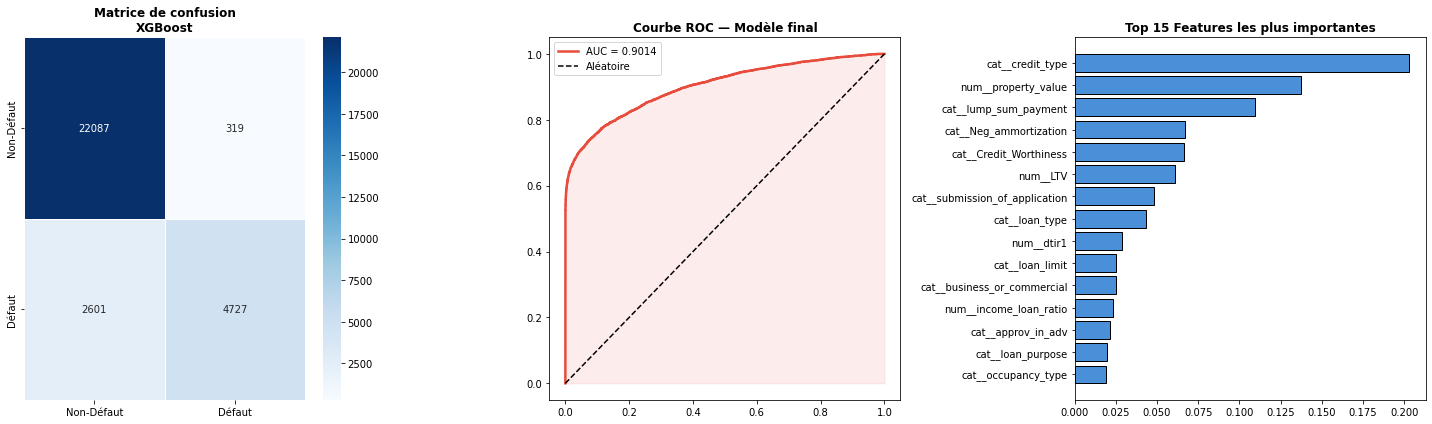

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final) # tableau croisé entre les réalités (y_test) et les prédictions (y_pred_final).
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Défaut','Défaut'],
            yticklabels=['Non-Défaut','Défaut'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Matrice de confusion\n{best_model_name}', fontsize=12, fontweight='bold')

#Courbe ROC finale
fpr, tpr, _ = roc_curve(y_test, y_proba_final)#Calcule le taux de vrais positifs (tpr) et le taux de faux positifs (fpr) pour différents seuils
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2.5, label=f'AUC = {auc_test:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, label='Aléatoire')#ligne du hasard
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')#colorie l'aire sous la courbe AUC
axes[1].set_title('Courbe ROC — Modèle final', fontsize=12, fontweight='bold')
axes[1].legend()

# features importance
clf = final_pipeline.named_steps['classifier']#on cherche le modèle xgboost à l'intérieur du pipeline
if hasattr(clf, 'feature_importances_'):
    # On essaie de récupérer les noms via le préprocesseur
    try:
        # On récupère automatiquement le nom de la première étape (le préprocesseur)
        prep_step_name = final_pipeline.steps[0][0]
        feat_names = final_pipeline.named_steps[prep_step_name].get_feature_names_out()
    except:
        # Si ça échoue, on crée des noms génériques pour ne pas bloquer le code
        feat_names = [f"Var_{i}" for i in range(len(clf.feature_importances_))]
    
    importances = clf.feature_importances_
    
    # On s'assure que les longueurs correspondent
    min_len = min(len(feat_names), len(importances))
    imp_df = pd.DataFrame({'Feature': feat_names[:min_len], 
                           'Importance': importances[:min_len]})
    
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)#on garde que 15 
    
    axes[2].barh(imp_df['Feature'], imp_df['Importance'], color='#4A90D9', edgecolor='black')
    axes[2].set_title('Top 15 Features les plus importantes', fontsize=12, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Importance non disponible', ha='center', va='center')

plt.tight_layout()
plt.show()

### Matrice de confusion : 
### True Négatifs (TN)	22 087: Les clients sains que le modèle a bien identifiés comme sains. C'est la gestion fluide de la banque.
### True Positifs (TP)	4 727:	Les clients en défaut que le modèle a bien détectés. C'est ici ou on évite des pertes d'argent.
### False Positifs (FP)	319:	L'erreur "commerciale" : le client est sain, mais le modèle l'a prédit en défaut. Ce sont les 319 bons clients que l'on risque de refuser à tort.
### False Négatifs (FN)	2 601:	L'erreur "financière" : le client va faire défaut, mais le modèle l'a prédit comme sain. Ce sont les clients qui vont coûter de l'argent à la banque.

### La Courbe ROC (La puissance globale)
### on a un AUC de 0.9014 : C'est le score d'un modèle "Excellent".
### le modèle est 90% plus efficace qu'un choix au hasard. La courbe monte très vite verticalement au début, ce qui prouve que le modèle identifie très rapidement les profils les plus risqués sans se tromper.
### Un AUC de 0.90 signifie que le modèle sépare presque parfaitement les deux types de clients. Les courbes de distribution des clients sains et des clients en défaut ne se chevauchent presque pas.

### L'analyse des features importance: 
### - le credit_type (Le plus important) : Le type de crédit est le premier indicateur de risque. Certains types de prêts sont statistiquement beaucoup plus fragiles que d'autres. Cela suggère que la nature même du contrat (crédit à la consommation, prêt immobilier ..) définit la probabilité de base du risque.
### - property_value : La valeur du bien immobilier, c'est la garantie de la banque. Si la valeur est faible ou instable, le risque augmente. Si le bien a une forte valeur, le risque final pour la banque est plus faible.
### - lump_sum_payment : La capacité à faire des remboursements forfaitaires. Cela traduit souvent la solidité financière du client.

### Le modèle final XGBoost présente une performance remarquable avec un AUC-ROC de 0.90. Il se distingue par une très haute précision, limitant les refus injustifiés à seulement 319 cas sur plus de 22 000 clients sains. L'analyse des variables décisionnelles place le type de crédit et la valeur du patrimoine comme les piliers de la détection du risque, validant ainsi la cohérence métier de l'algorithme."

## ÉTAPE 9: SAUVEGARDE DU MODÈLE FINAL

### Ici on va sauvegarder 2 fichiers: 
### -model_pipeline.pkl : Il contient le preprocessor (imputation, encodage, scaling) et le modèle XGBoost optimisé. cecii permet à l'application de traiter les nouvelles données exactement comme durant l'entraînement.
### -feature_info.pkl : Il contient la liste des colonnes numériques et catégorielles, utile pour que l'application Streamlit sache quels formulaires ou curseurs afficher à l'utilisateur.
### Le fichier feature_info.pkl agit comme une couche de métadonnées. Il assure la communication entre le modèle mathématique et l'interface utilisateur, garantissant que les données saisies sont structurées correctement et permettant une mise à jour dynamique de l'application sans modification du code source

In [46]:
# On sauvegarde TOUT le pipeline (preprocessing + modèle).
# Sauvegarde du cerveau (Le Pipeline)
joblib.dump(final_pipeline, 'model_pipeline.pkl')#fonction qui permet. de sauvegarder le pipeline entier. ainsi que la modèle xgboost entraîné
#Les métriques sont calculées avant avec classification report mais pas stockées proprement dans un format exploitable donc on les met dans un dict pour les sauvegarder
f1_final = f1_score(y_test, y_pred_final)#Calcul du F1-score final du meilleur modèle sur les données de test.
accuracy_final = accuracy_score(y_test, y_pred_final)#Calcul de l'accuracy finale du meilleur modèle sur les données de test.
# Sauvegarde des Métadonnées
feature_info = {
    'all_features':         X.columns.tolist(),#ici on précise quelles variables sont des nombres et lesquelles sont des catégories. Cela permettra à  l'application Streamlit de savoir s'il doit afficher un curseur (nombre) ou une liste déroulante (catégorie).
    'numerical_features':   num_features,
    'categorical_features': cat_features,
    'target_name':          'Status',
    'best_model_name':      'XGBoost',
    'auc_roc_test': round(auc_test, 4),
    'f1_test': round(f1_final, 4),
    'accuracy_test': round(accuracy_final, 4)
}
joblib.dump(feature_info, 'feature_info.pkl')

print(" Fichiers de production générés :")
print("   - 'model_pipeline.pkl' (Prétraitement + Modèle)")
print("   - 'feature_info.pkl'  (Noms des variables et scores)")

 Fichiers de production générés :
   - 'model_pipeline.pkl' (Prétraitement + Modèle)
   - 'feature_info.pkl'  (Noms des variables et scores)


In [47]:
#test de chargement et vérification
# On recharge le modèle et les features avec load
pipe_loaded = joblib.load('model_pipeline.pkl')
info_loaded = joblib.load('feature_info.pkl')

# On prend le tout premier client du jeu de test (X_test)
sample = X_test.iloc[[0]]

# On lance la prédiction avec le pipeline rechargé
pred   = pipe_loaded.predict(sample)[0]
proba  = pipe_loaded.predict_proba(sample)[0]#fonction qui donne le pourcentage de certitude.

print("Pipeline rechargé avec succès !")
print(f"Test sur 1 exemple (Premier client de X_test) :")
print(f"Modèle utilisé: {info_loaded['best_model_name']}")
print(f"Prédiction:{'Défaut (1)' if pred == 1 else 'Non-Défaut (0)'}")
print(f"Confiance Défaut:{proba[1]*100:.2f}%")
print(f"Valeur réelle:{'Défaut (1)' if y_test.iloc[0] == 1 else 'Non-Défaut (0)'}")

# Vérification de la cohérence des colonnes
if list(sample.columns) == info_loaded['all_features']:
    print("Cohérence des colonnes : OK")
else:
    print("L'ordre des colonnes diffère")

Pipeline rechargé avec succès !
Test sur 1 exemple (Premier client de X_test) :
Modèle utilisé: XGBoost
Prédiction:Non-Défaut (0)
Confiance Défaut:2.69%
Valeur réelle:Non-Défaut (0)
Cohérence des colonnes : OK


# FIN DU NOTEBOOK

In [48]:
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


In [50]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 loan_limit
['cf' nan 'ncf']

 Gender
['Sex Not Available' 'Male' 'Joint' 'Female']

 approv_in_adv
['nopre' 'pre' nan]

 loan_type
['type1' 'type2' 'type3']

 loan_purpose
['p1' 'p4' 'p3' 'p2' nan]

 Credit_Worthiness
['l1' 'l2']

 open_credit
['nopc' 'opc']

 business_or_commercial
['nob/c' 'b/c']

 Neg_ammortization
['not_neg' 'neg_amm' nan]

 interest_only
['not_int' 'int_only']

 lump_sum_payment
['not_lpsm' 'lpsm']

 construction_type
['sb' 'mh']

 occupancy_type
['pr' 'sr' 'ir']

 Secured_by
['home' 'land']

 total_units
['1U' '2U' '3U' '4U']

 credit_type
['EXP' 'EQUI' 'CRIF' 'CIB']

 co-applicant_credit_type
['CIB' 'EXP']

 age
['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25' nan]

 submission_of_application
['to_inst' 'not_inst' nan]

 Region
['south' 'North' 'central' 'North-East']

 Security_Type
['direct' 'Indriect']
